In [15]:
import pandas as pd
from pandas.api.types import CategoricalDtype
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
#Precisamos desta biblioteca para podermos escolher um ficheiro local
#Se o ficheiro vier por API ou tivermos um link, é so alterar a forma de import
from google.colab import files

# 1️⃣ Faz upload do ficheiro (vai abrir uma janela para escolher no teu PC)
uploaded = files.upload()

# 2️⃣ Guarda o nome do ficheiro (Colab mostra o nome depois do upload)
filename = list(uploaded.keys())[0]

# 3️⃣ Lê o Excel, por default lê sempre a primeira tab, por isso podemos usar o "sheet_name"
# Se tivermos dados em varias tabs, devemos usar uma Dataframe(df) para cada uma das tabs
df = pd.read_excel(filename, sheet_name='Credit_Risk_Dataset')
df.head()

Saving Credit_Risk_Dataset.xlsx to Credit_Risk_Dataset.xlsx


,ClientID,Age,Income,LoanAmount,LoanTerm,CreditScore,LatePayments,DebtToIncome,EmploymentType,Region,Outcome
0,C100000,59,4774,1268,36,324,4,0.57,Part-time,North,0
1,C100001,49,4067,5990,12,416,2,0.60,Part-time,North,1
2,C100002,35,1625,16034,12,781,8,0.16,Full-time,South,0
3,C100003,63,2316,7145,12,691,4,0.65,Full-time,South,0
4,C100004,28,3946,5732,24,836,4,0.29,Full-time,South,1


In [16]:
# Para garantir que podemos reproduzir os dados
np.random.seed(123)

In [19]:
# Selecionar X sem ClientID e Outcome
X = df.drop(["ClientID", "Outcome"], axis=1)
y = df["Outcome"]

# Transformar colunas categóricas em variáveis dummy
X = pd.get_dummies(X, drop_first=True)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    stratify=y,
    random_state=123
)

In [22]:
# Criar modelo
rf_model = RandomForestClassifier(
    n_estimators=2000,
    max_features=3,
    random_state=123,
    class_weight="balanced"  # corrige o desequilíbrio
)

# Treinar modelo
rf_model.fit(X_train, y_train)

# Ver modelo
print(rf_model)

RandomForestClassifier(class_weight='balanced', max_features=3,
                       n_estimators=2000, random_state=123)


Age: 0.1103
Income: 0.1254
LoanAmount: 0.1281
LoanTerm: 0.0617
CreditScore: 0.1921
LatePayments: 0.1607
DebtToIncome: 0.1610
EmploymentType_Part-time: 0.0146
EmploymentType_Self-employed: 0.0163
Region_North: 0.0145
Region_South: 0.0154


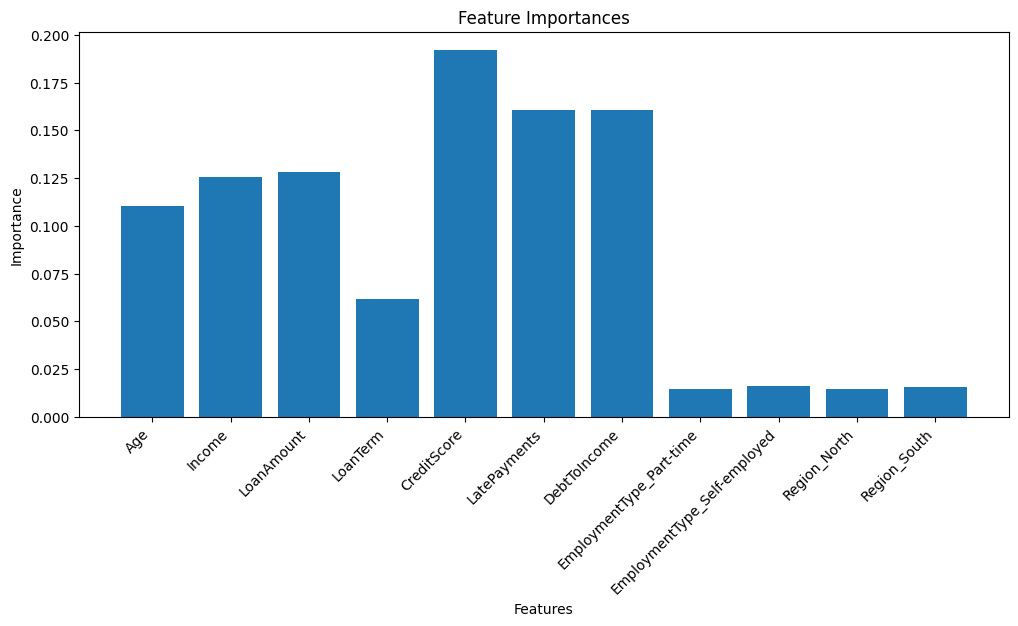

Confusion Matrix:
[[  3  28]
 [  4 115]]

Classification Report:
              precision    recall  f1-score   support

           0       0.43      0.10      0.16        31
           1       0.80      0.97      0.88       119

    accuracy                           0.79       150
   macro avg       0.62      0.53      0.52       150
weighted avg       0.73      0.79      0.73       150



In [23]:
# 1️⃣ Importância das features
importances = rf_model.feature_importances_
for name, importance in zip(X_train.columns, importances):
    print(f"{name}: {importance:.4f}")

plt.figure(figsize=(12,5))
plt.bar(X_train.columns, importances)
plt.title("Feature Importances")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.xticks(rotation=45, ha='right')  # rótulos girados para melhor leitura
plt.show()

# 3️⃣ Fazer previsões no conjunto de teste
predictions = rf_model.predict(X_test)

# 4️⃣ Avaliar modelo
from sklearn.metrics import confusion_matrix, classification_report

print("Confusion Matrix:")
print(confusion_matrix(y_test, predictions))

print("\nClassification Report:")
print(classification_report(y_test, predictions))

In [24]:
# 1️⃣ Matriz de confusão simples
cm = confusion_matrix(y_test, predictions)
cm_df = pd.DataFrame(cm, index=[0,1], columns=[0,1])  # garantir a ordem das classes
print("Confusion Matrix:")
print(cm_df)

# 2️⃣ Métricas detalhadas (precisão, recall, F1, suporte)
report = classification_report(y_test, predictions)
print("\nClassification Report:")
print(report)

Confusion Matrix:
   0    1
0  3   28
1  4  115

Classification Report:
              precision    recall  f1-score   support

           0       0.43      0.10      0.16        31
           1       0.80      0.97      0.88       119

    accuracy                           0.79       150
   macro avg       0.62      0.53      0.52       150
weighted avg       0.73      0.79      0.73       150



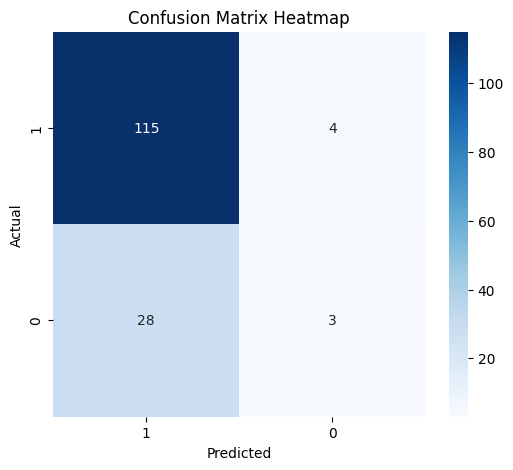

In [25]:
# Gerar matriz de confusão
cm = confusion_matrix(y_test, predictions, labels=y_test.unique())

# Criar DataFrame para labels
cm_df = pd.DataFrame(cm, index=y_test.unique(), columns=y_test.unique())

# Plotar heatmap
plt.figure(figsize=(6,5))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix Heatmap")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()